In [29]:
import cv2
import numpy as np
import configparser
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import tkinter as tk

## Konfiguráció beolvasása

In [30]:
config = configparser.ConfigParser()
config.read('config.ini')

IMG_SIZE = int(config['MODEL']['image_size'])
THRESHOLD = float(config['THRESHOLDS']['cosine_similarity_threshold'])

## Képek betöltése

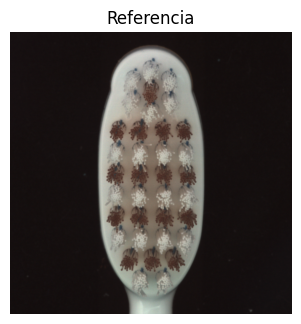

In [ ]:
# Kép elérési utak
import os


ref_path = "images/toothbrush/good/000.png"
good_images_dir = "images/toothbrush/good/"
broken_images_dir = "images/toothbrush/broken/"


ref_img = cv2.imread(ref_path)
ref_img = cv2.imread(ref_path)

def load_images_from_folder(folder, label):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, filename))
        if img is not None:
            images.append((img, label))
    return images

test_imgs = load_images_from_folder(good_images_dir, "good") + load_images_from_folder(broken_images_dir, "broken")

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(ref_img)
plt.title("Referencia")
plt.axis("off")
plt.show()

## Előfeldolgozás

In [ ]:
#Egyforma méretre hozás, ResNet50 → 224×224
ref_resized = cv2.resize(ref_img, (IMG_SIZE, IMG_SIZE))

test_resized = []
for i in range(len(test_imgs)):
   test_resized.append((cv2.resize(test_imgs[i][0], (IMG_SIZE, IMG_SIZE)), test_imgs[i][1]))

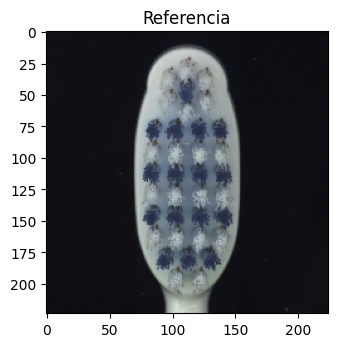

In [ ]:
#Színtér konverzió BGR → RGB

ref_img_rgb = cv2.cvtColor(ref_resized, cv2.COLOR_BGR2RGB)

test_imgs_rgb = []
for i in range(len(test_resized)):
    test_imgs_rgb.append((cv2.cvtColor(test_resized[i][0], cv2.COLOR_BGR2RGB), test_resized[i][1]))

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(ref_img_rgb)
plt.title("Referencia")
plt.show()

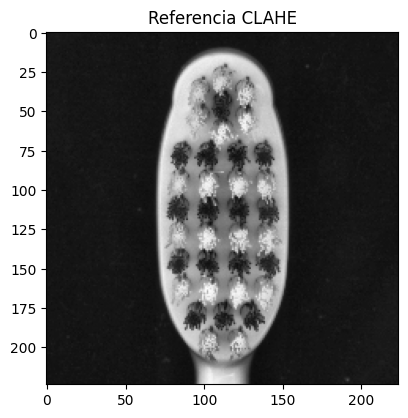

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#CLACHE szürke
def clahe_rgb(img, clipLimit=2.0, tileGridSize=(8,8)):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)
    clahe_img = clahe.apply(gray)
    clahe_rgb = cv2.cvtColor(clahe_img, cv2.COLOR_GRAY2RGB)
    return clahe_rgb

# def clahe_rgb(img, clipLimit=2.0, tileGridSize=(8,8)):
#     lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
#     l, a, b = cv2.split(lab)

#     clahe = cv2.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)
#     l_clahe = clahe.apply(l)

#     lab_clahe = cv2.merge((l_clahe, a, b))
#     return cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)

ref_img_clahe = clahe_rgb(ref_img_rgb)
test_imgs_clahe = []
for i in range(len(test_imgs_rgb)):
    test_imgs_clahe.append((clahe_rgb(test_imgs_rgb[i][0]), test_imgs_rgb[i][1]))

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(ref_img_clahe)
plt.title("Referencia CLAHE")
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9466563918143676..2.5877124183006535].


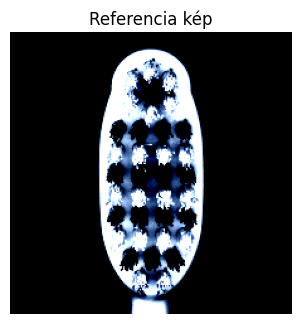

In [46]:
#Normalizálás
#Pixel értékek [0,1] tartományba: img/255.0
#CNN-eknél gyakran mean/std szerinti normalizáció ImageNet alapján:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

def normalize_image(img):
    img = img / 255.0
    img = (img - mean) / std
    return img

ref_img_normalized = normalize_image(ref_img_clahe)
test_imgs_normalized = []
for i in range(len(test_imgs_clahe)):
    test_imgs_normalized.append((normalize_image(test_imgs_clahe[i][0]), test_imgs_clahe[i][1]))

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(ref_img_normalized)
plt.title('Referencia kép')
plt.axis('off')

plt.show()

## Modell tesztelése, különböző rétegek futtatása

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D


base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

layer_names = [
    'conv2_block1_out',
    'conv2_block2_out',
    'conv2_block3_out',
    'conv3_block1_out',
    'conv3_block2_out',
    'conv3_block3_out',
    'conv3_block4_out',
    'conv4_block1_out',
    'conv4_block2_out',
    'conv4_block3_out',
    'conv4_block4_out',
    'conv5_block1_out',
    'conv5_block2_out',
    'conv5_block3_out'
]

layer_results = []

for feature_layer_name in layer_names:

    if feature_layer_name != 'avg_pool':
        feature_extractor = Model(inputs=base_model.input, outputs=base_model.get_layer(feature_layer_name).output)
    else:
        feature_extractor = Model(inputs=base_model.input,
                             outputs=GlobalAveragePooling2D()(base_model.output))

    ref_input = np.expand_dims(ref_img_normalized, axis=0)
    test_inputs = []
    for i in range(len(test_imgs_normalized)):
        test_inputs.append(np.expand_dims(test_imgs_normalized[i][0], axis=0))

    ref_features = feature_extractor.predict(ref_input, verbose=0)
    test_features = []
    for i in range(len(test_inputs)):
        test_features.append(feature_extractor.predict(test_inputs[i], verbose=0))

    # Cosine Similarity
    ref_vector = ref_features.flatten().reshape(1, -1)

    good_predictions = 0
    broken_predictions = 0
    predictions = []

    for i in range(len(test_features)):
        test_vector = test_features[i].flatten().reshape(1, -1)
        cosine_sim = cosine_similarity(ref_vector, test_vector)[0][0]
        label = test_imgs[i][1]
        prediction = "good" if cosine_sim >= THRESHOLD else "broken"
        predictions.append((test_imgs[i][0], prediction))
        #print(f"Kép {i+1} - Valós címke: {label}, Predikció: {prediction}, Cosine Similarity: {cosine_sim:.4f}")
        if label == prediction:
            if label == "good":
                good_predictions += 1
            else:
                broken_predictions += 1

    # print(f"\nHelyes jó képek predikciói: {good_predictions}/{len([img for img in test_imgs if img[1]=='good'])}")
    # print(f"Helyes törött képek predikciói: {broken_predictions}/{len([img for img in test_imgs if img[1]=='broken'])}")
    # print(f"\nRéteg neve: {feature_layer_name} - Összes helyes predikció: {good_predictions + broken_predictions}/{len(test_imgs)}" + " Százalék: " + f"{(good_predictions + broken_predictions)/len(test_imgs)*100:.2f}%")

    accuracy = (good_predictions + broken_predictions) / len(test_imgs) * 100
    accuracy = round(accuracy, 2)
    original_good_imgs = len([img for img in test_imgs if img[1]=='good'])
    original_broken_imgs = len([img for img in test_imgs if img[1]=='broken'])

    FN_good = original_good_imgs - good_predictions
    FP_good = original_broken_imgs - broken_predictions


    FN_broken = original_broken_imgs - broken_predictions
    FP_broken = original_good_imgs - good_predictions
    
    layer_results.append((feature_layer_name, accuracy, good_predictions, broken_predictions, original_good_imgs, original_broken_imgs, FN_good, FP_good, FN_broken, FP_broken))

# Kiértékelés

### Accuracy

In [38]:
print("\nRészletes eredmények rétegenként:")
for layer_name, accuracy, good_predictions, broken_predictions, original_good_imgs, original_broken_imgs, FN_good, FP_good, FN_broken, FP_broken in layer_results:
    print(f"Réteg: {layer_name}, Pontosság: {accuracy}%, Jó képek helyes predikciói: {good_predictions}/{original_good_imgs}, Törött képek helyes predikciói: {broken_predictions}/{original_broken_imgs}")


Részletes eredmények rétegenként:
Réteg: conv2_block1_out, Pontosság: 28.57%, Jó képek helyes predikciói: 12/12, Törött képek helyes predikciói: 0/30
Réteg: conv2_block2_out, Pontosság: 28.57%, Jó képek helyes predikciói: 12/12, Törött képek helyes predikciói: 0/30
Réteg: conv2_block3_out, Pontosság: 28.57%, Jó képek helyes predikciói: 12/12, Törött képek helyes predikciói: 0/30
Réteg: conv3_block1_out, Pontosság: 28.57%, Jó képek helyes predikciói: 12/12, Törött képek helyes predikciói: 0/30
Réteg: conv3_block2_out, Pontosság: 38.1%, Jó képek helyes predikciói: 12/12, Törött képek helyes predikciói: 4/30
Réteg: conv3_block3_out, Pontosság: 28.57%, Jó képek helyes predikciói: 12/12, Törött képek helyes predikciói: 0/30
Réteg: conv3_block4_out, Pontosság: 28.57%, Jó képek helyes predikciói: 12/12, Törött képek helyes predikciói: 0/30
Réteg: conv4_block1_out, Pontosság: 33.33%, Jó képek helyes predikciói: 12/12, Törött képek helyes predikciói: 2/30
Réteg: conv4_block2_out, Pontosság: 50

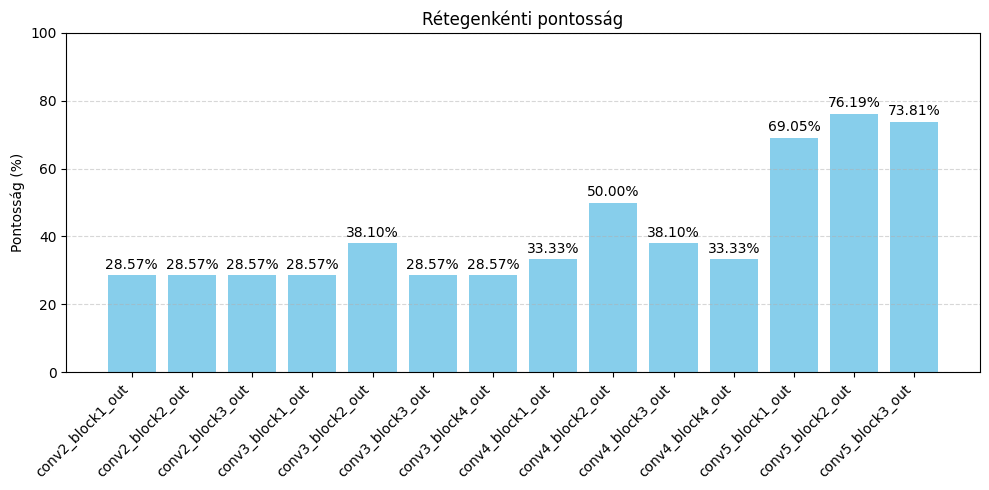

In [39]:
layers = [x[0] for x in layer_results]
accuracies = [x[1] for x in layer_results]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(layers, accuracies, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Pontosság (%)')
plt.ylim(0, 100)
plt.title('Rétegenkénti pontosság')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', va='bottom')

plt.tight_layout()
plt.show()


### Balanced accuracy és F1 score

In [ ]:
layer_results_balanced = []
layer_results_f1score = []

for layer_name, accuracy, good_pred, broken_pred, total_good, total_broken, FN_good, FP_good, FN_broken, FP_broken in layer_results:

    good_recall = good_pred / total_good if total_good > 0 else 0
    broken_recall = broken_pred / total_broken if total_broken > 0 else 0

    good_precision = good_pred / (good_pred + FP_good) if (good_pred + FP_good) > 0 else 0
    broken_precision = broken_pred / (broken_pred + FP_broken) if (broken_pred + FP_broken) > 0 else 0
    
    # Balanced accuracy (%)
    balanced_acc = round((good_recall + broken_recall) / 2 * 100, 2)
    
    # Eredmények tárolása
    layer_results_balanced.append((layer_name, balanced_acc, good_recall, broken_recall))

    f1_good = (
        2 * good_precision * good_recall / (good_precision + good_recall)
        if (good_precision + good_recall) > 0 else 0
    )

    f1_broken = (
        2 * broken_precision * broken_recall / (broken_precision + broken_recall)
        if (broken_precision + broken_recall) > 0 else 0
    )

    f1_macro = round((f1_good + f1_broken) / 2 * 100, 2)

    layer_results_f1score.append((layer_name, f1_macro))

In [41]:
print("Balanced pontosság rétegenként:")
for layer_name, balanced_acc, good_recall, broken_recall in layer_results_balanced:
    print(f"{layer_name}: {balanced_acc}% (Good recall: {good_recall:.2f}, Broken recall: {broken_recall:.2f})")


Balanced pontosság rétegenként:
conv2_block1_out: 50.0% (Good recall: 1.00, Broken recall: 0.00)
conv2_block2_out: 50.0% (Good recall: 1.00, Broken recall: 0.00)
conv2_block3_out: 50.0% (Good recall: 1.00, Broken recall: 0.00)
conv3_block1_out: 50.0% (Good recall: 1.00, Broken recall: 0.00)
conv3_block2_out: 56.67% (Good recall: 1.00, Broken recall: 0.13)
conv3_block3_out: 50.0% (Good recall: 1.00, Broken recall: 0.00)
conv3_block4_out: 50.0% (Good recall: 1.00, Broken recall: 0.00)
conv4_block1_out: 53.33% (Good recall: 1.00, Broken recall: 0.07)
conv4_block2_out: 65.0% (Good recall: 1.00, Broken recall: 0.30)
conv4_block3_out: 56.67% (Good recall: 1.00, Broken recall: 0.13)
conv4_block4_out: 53.33% (Good recall: 1.00, Broken recall: 0.07)
conv5_block1_out: 55.83% (Good recall: 0.25, Broken recall: 0.87)
conv5_block2_out: 60.83% (Good recall: 0.25, Broken recall: 0.97)
conv5_block3_out: 54.17% (Good recall: 0.08, Broken recall: 1.00)


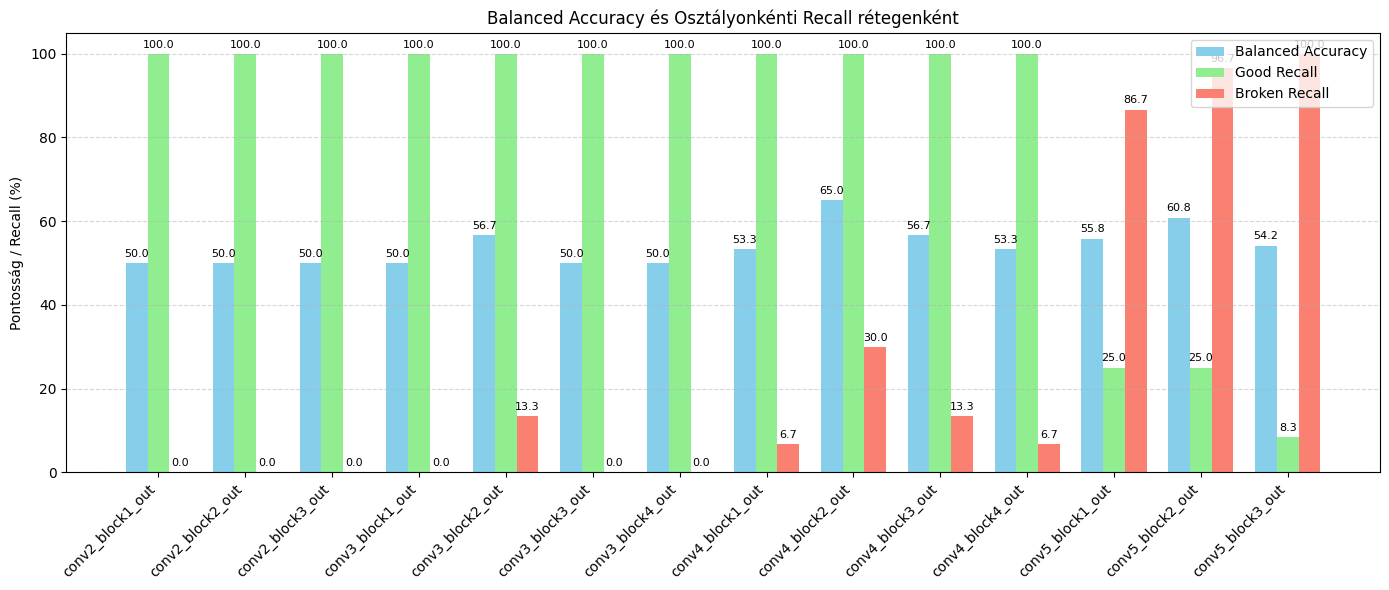

In [42]:
import matplotlib.pyplot as plt
import numpy as np

layers = [x[0] for x in layer_results_balanced]
balanced_acc = [x[1] for x in layer_results_balanced]
good_recall = [x[2]*100 for x in layer_results_balanced]
broken_recall = [x[3]*100 for x in layer_results_balanced]

x = np.arange(len(layers))
width = 0.25

plt.figure(figsize=(14,6))

plt.bar(x - width, balanced_acc, width, label='Balanced Accuracy', color='skyblue')

plt.bar(x, good_recall, width, label='Good Recall', color='lightgreen')
plt.bar(x + width, broken_recall, width, label='Broken Recall', color='salmon')

plt.xticks(x, layers, rotation=45, ha='right')
plt.ylabel('Pontosság / Recall (%)')
plt.ylim(0, 105)
plt.title('Balanced Accuracy és Osztályonkénti Recall rétegenként')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i in range(len(layers)):
    plt.text(i - width, balanced_acc[i]+1, f"{balanced_acc[i]:.1f}", ha='center', va='bottom', fontsize=8)
    plt.text(i, good_recall[i]+1, f"{good_recall[i]:.1f}", ha='center', va='bottom', fontsize=8)
    plt.text(i + width, broken_recall[i]+1, f"{broken_recall[i]:.1f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


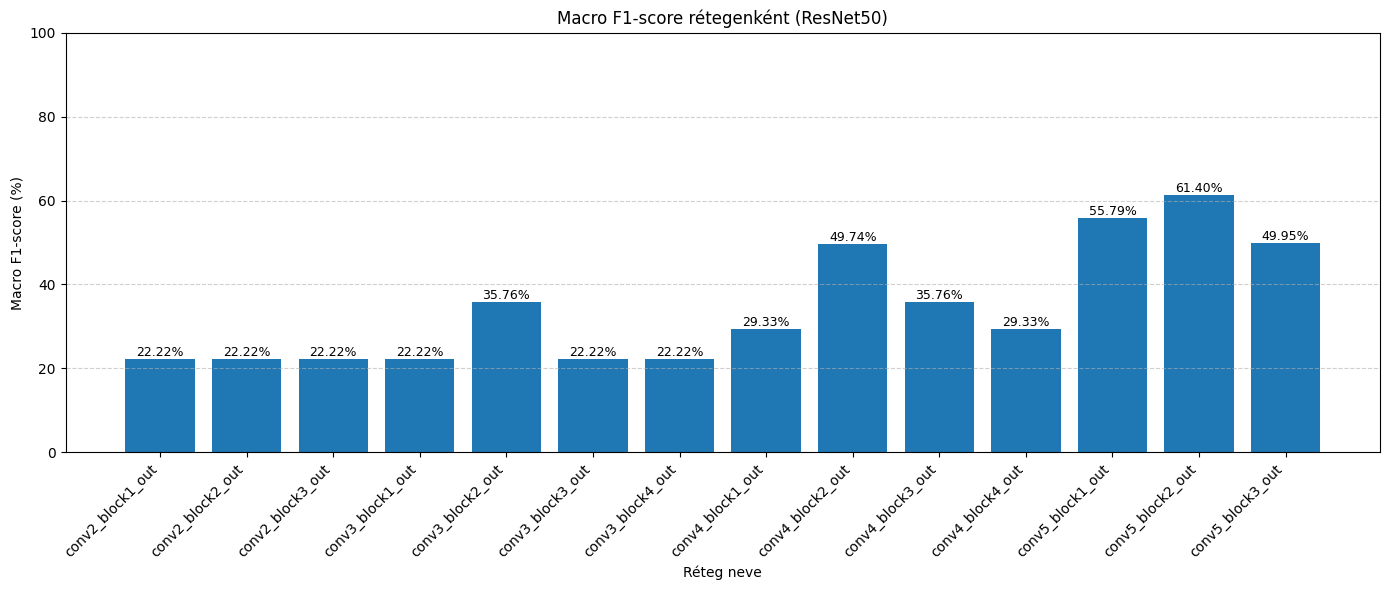

In [45]:
import matplotlib.pyplot as plt

layer_names = [r[0] for r in layer_results_f1score]
f1_scores = [r[1] for r in layer_results_f1score]

plt.figure(figsize=(14, 6))
bars = plt.bar(layer_names, f1_scores)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Macro F1-score (%)")
plt.xlabel("Réteg neve")
plt.title("Macro F1-score rétegenként (ResNet50)")
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Értékek kiírása az oszlopokra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}%",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

## Parameter tuning

### A legjobban szerepelt rétegek, conv4_block1, conv5_block1

# conv4_block1

In [47]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D


base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

layer_name = 'conv4_block1_out'

threshold_values = [0.970, 0.971, 0.972, 0.973, 0.974, 0.975, 0.976, 0.977, 0.978, 0.979, 0.980, 0.981, 0.982, 0.983, 0.984, 0.985, 0.986, 0.987, 0.988, 0.989, 0.990]

layer_results = []

feature_extractor = Model(inputs=base_model.input, outputs=base_model.get_layer(layer_name).output)

for threshold in threshold_values:

    ref_input = np.expand_dims(ref_img_normalized, axis=0)
    test_inputs = []
    for i in range(len(test_imgs_normalized)):
        test_inputs.append(np.expand_dims(test_imgs_normalized[i][0], axis=0))

    ref_features = feature_extractor.predict(ref_input, verbose=0)
    test_features = []
    for i in range(len(test_inputs)):
        test_features.append(feature_extractor.predict(test_inputs[i], verbose=0))

    ref_vector = ref_features.flatten().reshape(1, -1)

    good_predictions = 0
    broken_predictions = 0
    predictions = []

    for i in range(len(test_features)):
        test_vector = test_features[i].flatten().reshape(1, -1)
        cosine_sim = cosine_similarity(ref_vector, test_vector)[0][0]
        label = test_imgs[i][1]
        prediction = "good" if cosine_sim >= threshold else "broken"
        predictions.append((test_imgs[i][0], prediction))
        if label == prediction:
            if label == "good":
                good_predictions += 1
            else:
                broken_predictions += 1

    accuracy = (good_predictions + broken_predictions) / len(test_imgs) * 100
    accuracy = round(accuracy, 2)
    original_good_imgs = len([img for img in test_imgs if img[1]=='good'])
    original_broken_imgs = len([img for img in test_imgs if img[1]=='broken'])

    FN_good = original_good_imgs - good_predictions
    FP_good = original_broken_imgs - broken_predictions


    FN_broken = original_broken_imgs - broken_predictions
    FP_broken = original_good_imgs - good_predictions
    layer_results.append((threshold, accuracy, good_predictions, broken_predictions, original_good_imgs, original_broken_imgs, FN_good, FP_good, FN_broken, FP_broken))



## Accuracy

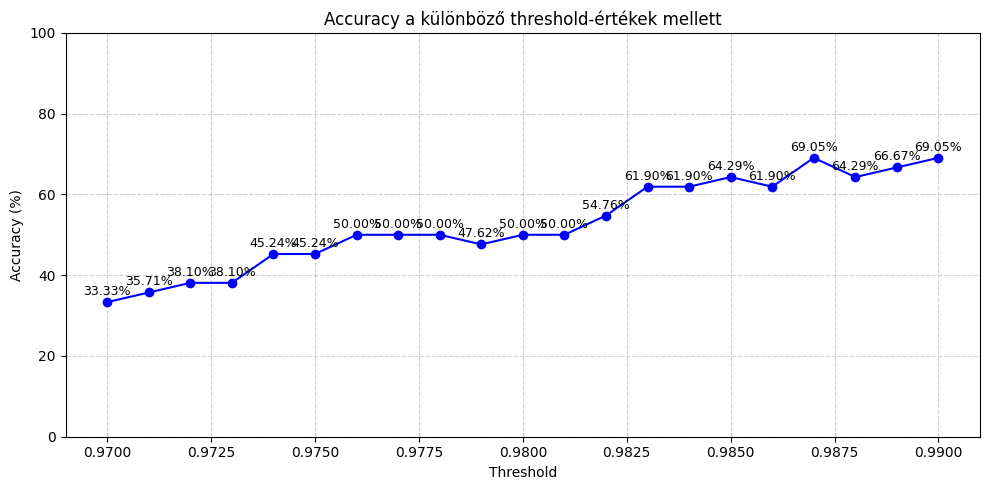

In [48]:
import matplotlib.pyplot as plt

# Küszöbértékek és accuracy-k kinyerése
thresholds = [r[0] for r in layer_results]
accuracies = [r[1] for r in layer_results]

plt.figure(figsize=(10,5))
plt.plot(thresholds, accuracies, marker='o', linestyle='-', color='b')

plt.title("Accuracy a különböző threshold-értékek mellett")
plt.xlabel("Threshold")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)  # fix 0-100 skála
plt.grid(True, linestyle='--', alpha=0.6)

# Pontok értékének kiírása
for t, acc in zip(thresholds, accuracies):
    plt.text(t, acc + 1, f"{acc:.2f}%", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## Balanced accuracy és F1 score

In [49]:
layer_results_balanced = []
layer_results_f1score = []

for threshold, accuracy, good_pred, broken_pred, total_good, total_broken, FN_good, FP_good, FN_broken, FP_broken in layer_results:
    # Osztályonkénti recall
    good_recall = good_pred / total_good if total_good > 0 else 0
    broken_recall = broken_pred / total_broken if total_broken > 0 else 0

    # Osztályonkénti precision
    good_precision = good_pred / (good_pred + FP_good) if (good_pred + FP_good) > 0 else 0
    broken_precision = broken_pred / (broken_pred + FP_broken) if (broken_pred + FP_broken) > 0 else 0
    
    # Balanced accuracy (%)
    balanced_acc = round((good_recall + broken_recall) / 2 * 100, 2)
    
    # Eredmények tárolása
    layer_results_balanced.append((threshold, balanced_acc, good_recall, broken_recall))

    f1_good = (
        2 * good_precision * good_recall / (good_precision + good_recall)
        if (good_precision + good_recall) > 0 else 0
    )

    f1_broken = (
        2 * broken_precision * broken_recall / (broken_precision + broken_recall)
        if (broken_precision + broken_recall) > 0 else 0
    )

    f1_macro = round((f1_good + f1_broken) / 2 * 100, 2)

    layer_results_f1score.append((threshold, f1_macro))

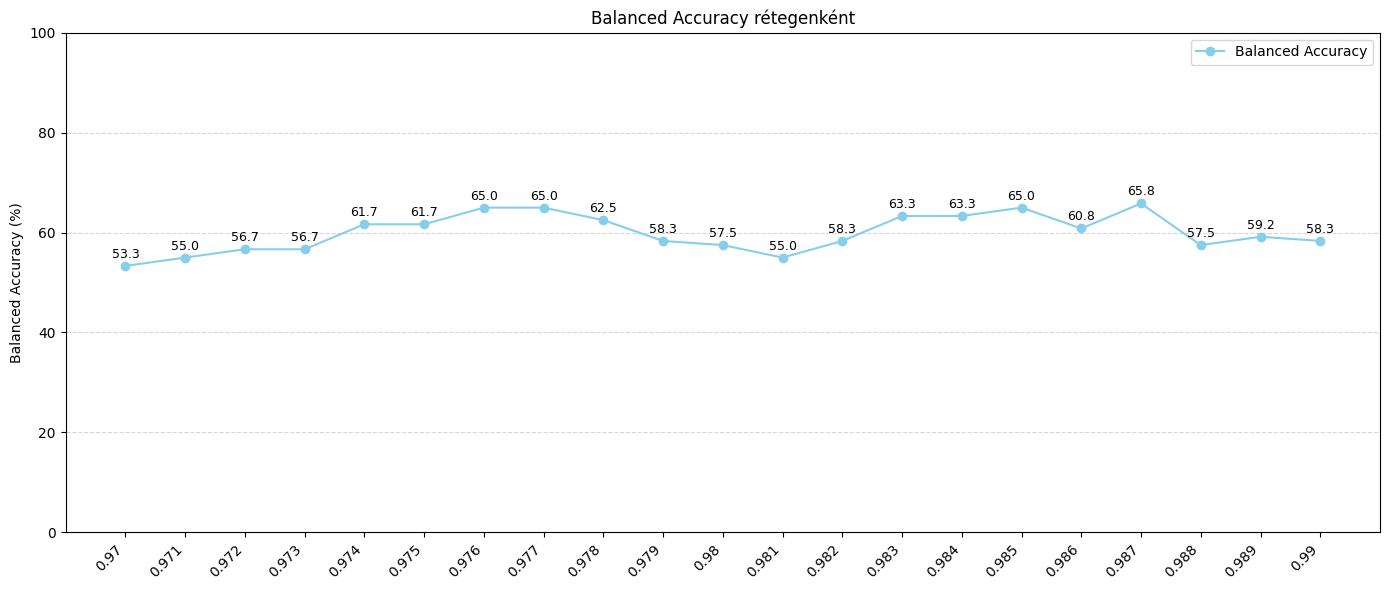

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# Layer nevek és balanced accuracy értékek
layers = [x[0] for x in layer_results_balanced]
balanced_acc = [x[1] for x in layer_results_balanced]

x = np.arange(len(layers))  # X pozíciók a rétegekhez

plt.figure(figsize=(14,6))

# Vonaldiagram
plt.plot(x, balanced_acc, marker='o', linestyle='-', color='skyblue', label='Balanced Accuracy')

# Pontok értéke a vonalon
for i, acc in enumerate(balanced_acc):
    plt.text(i, acc + 1, f"{acc:.1f}", ha='center', va='bottom', fontsize=9)

# Címkék, tengelyek, stílus
plt.xticks(x, layers, rotation=45, ha='right')
plt.ylabel('Balanced Accuracy (%)')
plt.ylim(0, 100)  # mindig 0-100%
plt.title('Balanced Accuracy rétegenként')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()


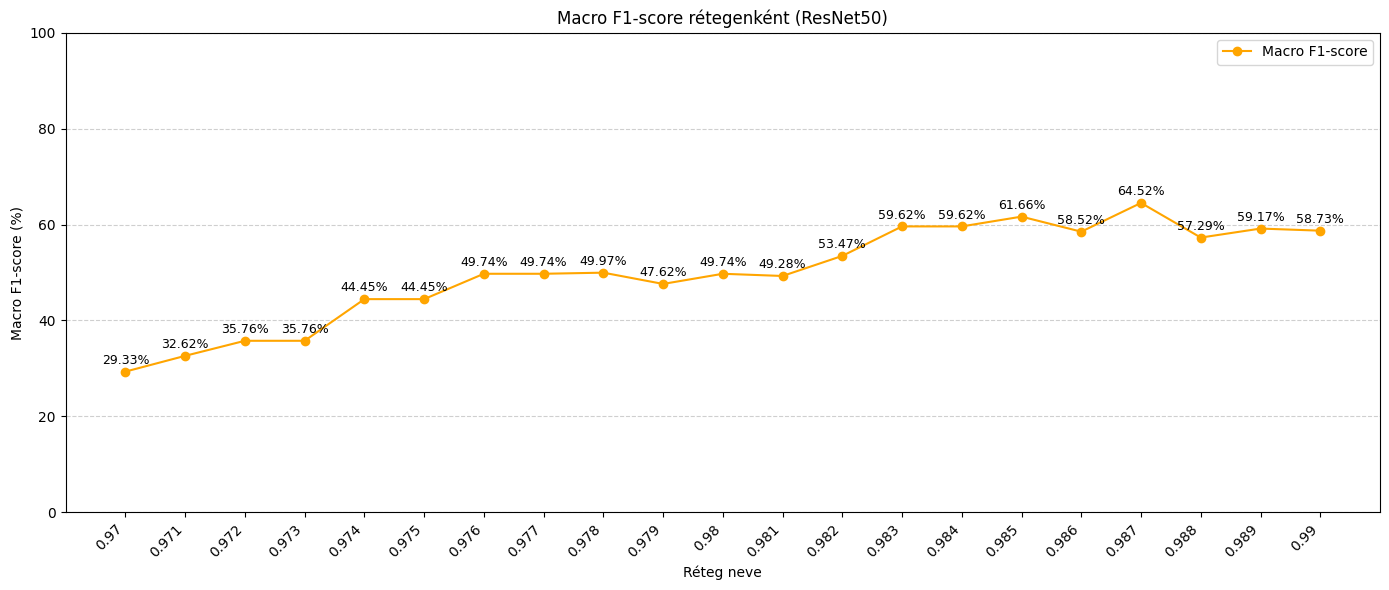

In [51]:
import matplotlib.pyplot as plt
import numpy as np

layer_names = [r[0] for r in layer_results_f1score]
f1_scores = [r[1] for r in layer_results_f1score]

x = np.arange(len(layer_names))  # X pozíciók a rétegekhez

plt.figure(figsize=(14,6))

# Vonaldiagram
plt.plot(x, f1_scores, marker='o', linestyle='-', color='orange', label='Macro F1-score')

# Pontok fölé kiírjuk az értékeket
for i, score in enumerate(f1_scores):
    plt.text(i, score + 1, f"{score:.2f}%", ha='center', va='bottom', fontsize=9)

# Címkék és stílus
plt.xticks(x, layer_names, rotation=45, ha='right')
plt.ylabel("Macro F1-score (%)")
plt.xlabel("Réteg neve")
plt.title("Macro F1-score rétegenként (ResNet50)")
plt.ylim(0, 100)  # fix skála 0-100%
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()


# conv5_block1

In [52]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D


base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

layer_name = 'conv5_block1_out'

threshold_values = [0.965, 0.966, 0.967, 0.968, 0.969, 0.970, 0.971, 0.972, 0.973, 0.974, 0.975, 0.976, 0.977, 0.978, 0.979, 0.980, 0.981, 0.982, 0.983, 0.984, 0.985]

layer_results = []

feature_extractor = Model(inputs=base_model.input, outputs=base_model.get_layer(layer_name).output)

for threshold in threshold_values:

    ref_input = np.expand_dims(ref_img_normalized, axis=0)
    test_inputs = []
    for i in range(len(test_imgs_normalized)):
        test_inputs.append(np.expand_dims(test_imgs_normalized[i][0], axis=0))

    ref_features = feature_extractor.predict(ref_input, verbose=0)
    test_features = []
    for i in range(len(test_inputs)):
        test_features.append(feature_extractor.predict(test_inputs[i], verbose=0))

    ref_vector = ref_features.flatten().reshape(1, -1)

    good_predictions = 0
    broken_predictions = 0
    predictions = []

    for i in range(len(test_features)):
        test_vector = test_features[i].flatten().reshape(1, -1)
        cosine_sim = cosine_similarity(ref_vector, test_vector)[0][0]
        label = test_imgs[i][1]
        prediction = "good" if cosine_sim >= threshold else "broken"
        predictions.append((test_imgs[i][0], prediction))
        if label == prediction:
            if label == "good":
                good_predictions += 1
            else:
                broken_predictions += 1

    accuracy = (good_predictions + broken_predictions) / len(test_imgs) * 100
    accuracy = round(accuracy, 2)
    original_good_imgs = len([img for img in test_imgs if img[1]=='good'])
    original_broken_imgs = len([img for img in test_imgs if img[1]=='broken'])

    FN_good = original_good_imgs - good_predictions
    FP_good = original_broken_imgs - broken_predictions


    FN_broken = original_broken_imgs - broken_predictions
    FP_broken = original_good_imgs - good_predictions
    layer_results.append((threshold, accuracy, good_predictions, broken_predictions, original_good_imgs, original_broken_imgs, FN_good, FP_good, FN_broken, FP_broken))



## Accuracy

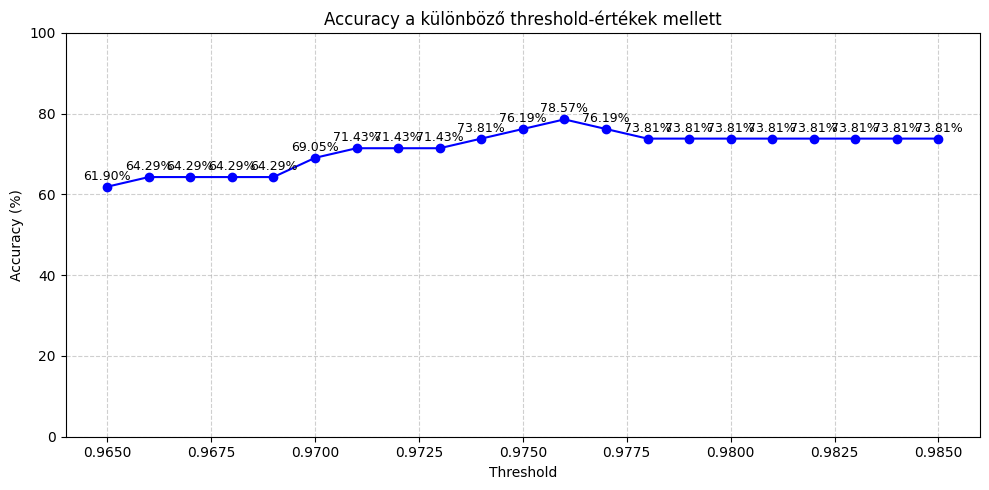

In [53]:
import matplotlib.pyplot as plt

# Küszöbértékek és accuracy-k kinyerése
thresholds = [r[0] for r in layer_results]
accuracies = [r[1] for r in layer_results]

plt.figure(figsize=(10,5))
plt.plot(thresholds, accuracies, marker='o', linestyle='-', color='b')

plt.title("Accuracy a különböző threshold-értékek mellett")
plt.xlabel("Threshold")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)  # fix 0-100 skála
plt.grid(True, linestyle='--', alpha=0.6)

# Pontok értékének kiírása
for t, acc in zip(thresholds, accuracies):
    plt.text(t, acc + 1, f"{acc:.2f}%", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## Balanced accuracy és F1 score

In [54]:
layer_results_balanced = []
layer_results_f1score = []

for threshold, accuracy, good_pred, broken_pred, total_good, total_broken, FN_good, FP_good, FN_broken, FP_broken in layer_results:
    # Osztályonkénti recall
    good_recall = good_pred / total_good if total_good > 0 else 0
    broken_recall = broken_pred / total_broken if total_broken > 0 else 0

    # Osztályonkénti precision
    good_precision = good_pred / (good_pred + FP_good) if (good_pred + FP_good) > 0 else 0
    broken_precision = broken_pred / (broken_pred + FP_broken) if (broken_pred + FP_broken) > 0 else 0
    
    # Balanced accuracy (%)
    balanced_acc = round((good_recall + broken_recall) / 2 * 100, 2)
    
    # Eredmények tárolása
    layer_results_balanced.append((threshold, balanced_acc, good_recall, broken_recall))

    f1_good = (
        2 * good_precision * good_recall / (good_precision + good_recall)
        if (good_precision + good_recall) > 0 else 0
    )

    f1_broken = (
        2 * broken_precision * broken_recall / (broken_precision + broken_recall)
        if (broken_precision + broken_recall) > 0 else 0
    )

    f1_macro = round((f1_good + f1_broken) / 2 * 100, 2)

    layer_results_f1score.append((threshold, f1_macro))

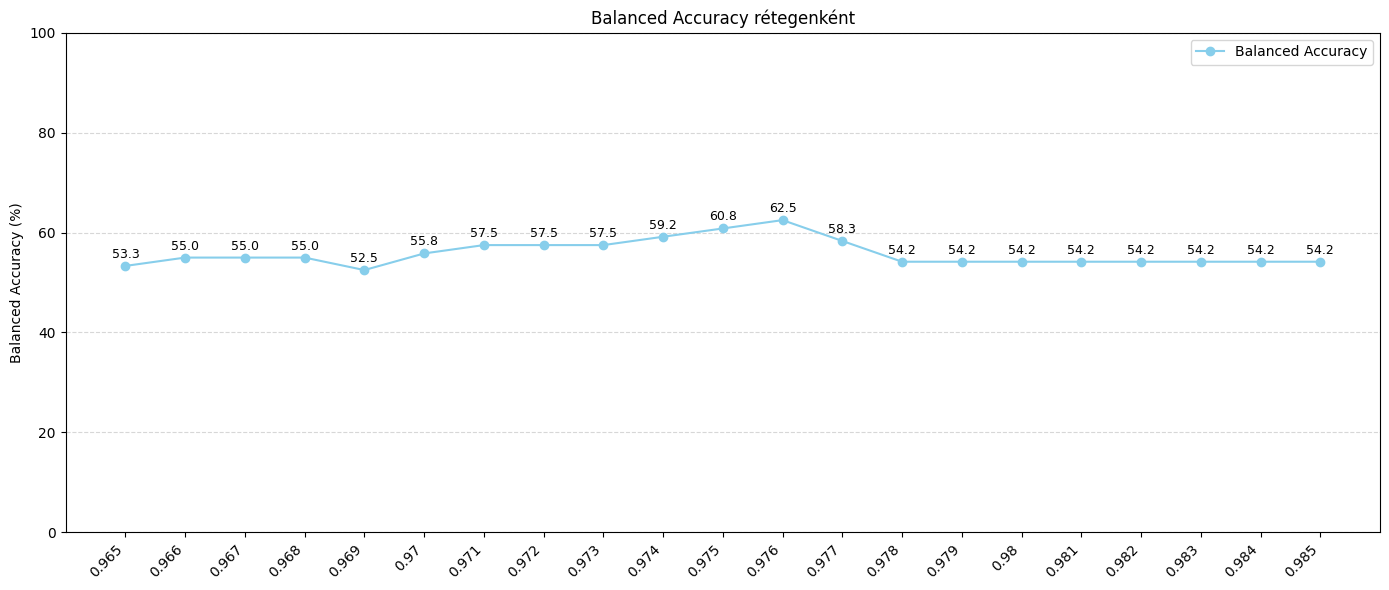

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# Layer nevek és balanced accuracy értékek
layers = [x[0] for x in layer_results_balanced]
balanced_acc = [x[1] for x in layer_results_balanced]

x = np.arange(len(layers))  # X pozíciók a rétegekhez

plt.figure(figsize=(14,6))

# Vonaldiagram
plt.plot(x, balanced_acc, marker='o', linestyle='-', color='skyblue', label='Balanced Accuracy')

# Pontok értéke a vonalon
for i, acc in enumerate(balanced_acc):
    plt.text(i, acc + 1, f"{acc:.1f}", ha='center', va='bottom', fontsize=9)

# Címkék, tengelyek, stílus
plt.xticks(x, layers, rotation=45, ha='right')
plt.ylabel('Balanced Accuracy (%)')
plt.ylim(0, 100)  # mindig 0-100%
plt.title('Balanced Accuracy rétegenként')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()


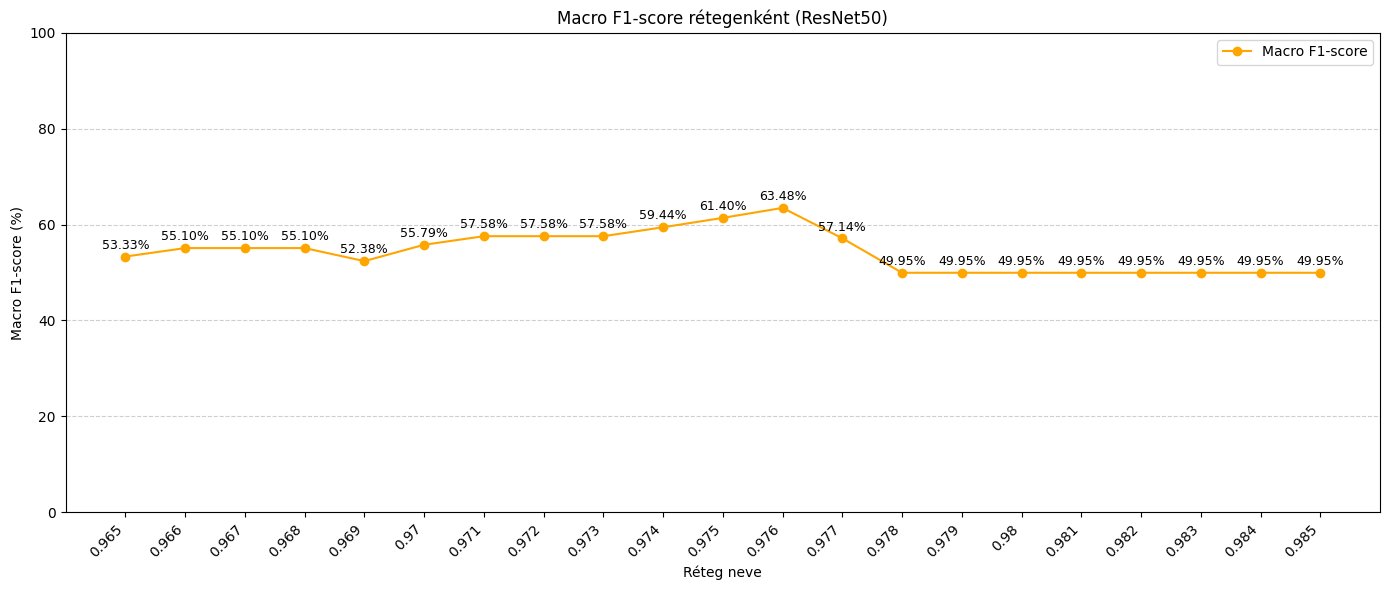

In [56]:
import matplotlib.pyplot as plt
import numpy as np

layer_names = [r[0] for r in layer_results_f1score]
f1_scores = [r[1] for r in layer_results_f1score]

x = np.arange(len(layer_names))  # X pozíciók a rétegekhez

plt.figure(figsize=(14,6))

# Vonaldiagram
plt.plot(x, f1_scores, marker='o', linestyle='-', color='orange', label='Macro F1-score')

# Pontok fölé kiírjuk az értékeket
for i, score in enumerate(f1_scores):
    plt.text(i, score + 1, f"{score:.2f}%", ha='center', va='bottom', fontsize=9)

# Címkék és stílus
plt.xticks(x, layer_names, rotation=45, ha='right')
plt.ylabel("Macro F1-score (%)")
plt.xlabel("Réteg neve")
plt.title("Macro F1-score rétegenként (ResNet50)")
plt.ylim(0, 100)  # fix skála 0-100%
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()


In [57]:
feature_layer_name = 'conv4_block1_out' 

feature_extractor = Model(inputs=base_model.input, 
                          outputs=base_model.get_layer(feature_layer_name).output)


ref_input = np.expand_dims(ref_img_normalized, axis=0)
test_inputs = []
for i in range(len(test_imgs_normalized)):
    test_inputs.append(np.expand_dims(test_imgs_normalized[i][0], axis=0))

ref_features = feature_extractor.predict(ref_input, verbose=0)
test_features = []
for i in range(len(test_inputs)):
    test_features.append(feature_extractor.predict(test_inputs[i], verbose=0))



feature_diff_sq = []
for i in range(len(test_features)):
    feature_diff_sq.append((np.squeeze(ref_features) - np.squeeze(test_features[i])) ** 2)

anomaly_map = []
for i in range(len(feature_diff_sq)):
    anomaly_map.append(np.mean(feature_diff_sq[i], axis=-1))  # Átlagolás a csatornák mentén

anomaly_map_normalized = []
for i in range(len(anomaly_map)):
    norm_map = (anomaly_map[i] - np.min(anomaly_map[i])) / (np.max(anomaly_map[i]) - np.min(anomaly_map[i]))
    anomaly_map_normalized.append(norm_map)

output_dir = "heatmaps/toothbrush"
os.makedirs(output_dir, exist_ok=True)

for i in range(len(anomaly_map_normalized)):
    heatmap = cv2.resize(anomaly_map_normalized[i], (IMG_SIZE, IMG_SIZE))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    clahe_img_uint8 = np.uint8(test_imgs_clahe[i][0] * 255)
    clahe_img_bgr = cv2.cvtColor(clahe_img_uint8, cv2.COLOR_RGB2BGR)
    alpha = 0.5
    overlay = cv2.addWeighted(clahe_img_bgr, 1 - alpha, heatmap_color, alpha, 0)
    output_path = os.path.join(output_dir, f"heatmap_overlay_{i+1}.png")
    cv2.imwrite(output_path, overlay)

# for i in range(len(anomaly_map_normalized)):
#     heatmap = cv2.resize(anomaly_map_normalized[i], (IMG_SIZE, IMG_SIZE))

#     if predictions[i][1] == "broken":
#         plt.figure(figsize=(8, 6))
#         plt.imshow(test_imgs_clahe[i][0]) # Az eredeti (CLAHE) teszt kép
#         plt.imshow(heatmap, cmap='jet', alpha=0.5) # Áttetsző hőtérkép rajta
#         plt.title("Hiba Detektálása (ResNet50 Jellemzők Alapján)")
#         plt.colorbar(label="Eltérés mértéke")
#         plt.axis('off')
#         plt.show()

C:\Users\beres\AppData\Local\Temp\ipykernel_19540\1902515610.py:29: RuntimeWarning: invalid value encountered in divide
  norm_map = (anomaly_map[i] - np.min(anomaly_map[i])) / (np.max(anomaly_map[i]) - np.min(anomaly_map[i]))
C:\Users\beres\AppData\Local\Temp\ipykernel_19540\1902515610.py:37: RuntimeWarning: invalid value encountered in cast
  heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
